In [19]:
import pandas as pd

df = pd.read_csv('data/synthetic_customer_churn_100k.csv')

df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [20]:
df.shape

(100000, 9)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


In [22]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True)

df.head()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,Gender_Other,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,56,68,147.58,10052.03,0,False,False,False,True,False,False,False
1,2,69,32,22.54,686.78,0,True,False,False,False,False,False,True
2,3,46,10,52.47,537.88,0,False,False,True,False,False,True,False
3,4,32,22,109.67,2390.04,1,True,False,False,False,False,False,True
4,5,60,54,130.98,7081.28,0,False,False,False,False,True,False,False


In [23]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

C:\Users\MAYURESH PARCHE\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [31]:
y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.69095


In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[9123 4171]
 [2010 4696]]


After applying class balancing, recall for churn increased significantly from 47% to 70%, reducing missed churn cases by over 40%. Although accuracy dropped slightly, the model is now more effective from a business perspective as it identifies more at-risk customers

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.69      0.75     13294
           1       0.53      0.70      0.60      6706

    accuracy                           0.69     20000
   macro avg       0.67      0.69      0.68     20000
weighted avg       0.72      0.69      0.70     20000



In [36]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
11,PaymentMethod_Mailed check,1.219589e-01
9,PaymentMethod_Credit card,6.554644e-02
6,Gender_Other,6.149222e-02
5,Gender_Male,3.518694e-02
10,PaymentMethod_Electronic check,2.296857e-02
3,MonthlyCharges,1.355527e-02
1,Age,7.329577e-04
4,TotalCharges,9.792851e-05
0,CustomerID,3.139042e-07
2,Tenure,-3.213803e-02


In [37]:
feature_importance.tail(10)

,Feature,Importance
6,Gender_Other,6.149222e-02
5,Gender_Male,3.518694e-02
10,PaymentMethod_Electronic check,2.296857e-02
3,MonthlyCharges,1.355527e-02
1,Age,7.329577e-04
4,TotalCharges,9.792851e-05
0,CustomerID,3.139042e-07
2,Tenure,-3.213803e-02
7,Contract_One year,-1.698023e+00
8,Contract_Two year,-1.728580e+00


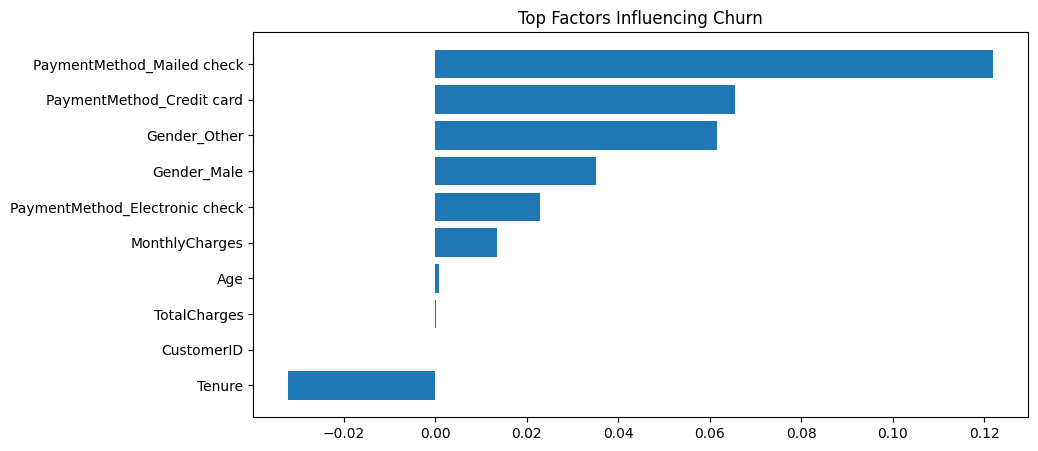

In [38]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top Factors Influencing Churn")
plt.show()

In [39]:
feature_importance.head(10)

,Feature,Importance
11,PaymentMethod_Mailed check,1.219589e-01
9,PaymentMethod_Credit card,6.554644e-02
6,Gender_Other,6.149222e-02
5,Gender_Male,3.518694e-02
10,PaymentMethod_Electronic check,2.296857e-02
3,MonthlyCharges,1.355527e-02
1,Age,7.329577e-04
4,TotalCharges,9.792851e-05
0,CustomerID,3.139042e-07
2,Tenure,-3.213803e-02


In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [52]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

In [53]:
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
y_pred_rf = rf_model.predict(X_test)

In [55]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[10780  2514]
 [ 2518  4188]]
              precision    recall  f1-score   support

           0       0.81      0.81      0.81     13294
           1       0.62      0.62      0.62      6706

    accuracy                           0.75     20000
   macro avg       0.72      0.72      0.72     20000
weighted avg       0.75      0.75      0.75     20000

